# Analyzing the Relationship Between Daily Habits and Productivity

This notebook presents the data collection, exploratory data analysis (EDA), and statistical modeling of daily habits and their effect on productivity.

In [32]:
import pandas as pd

In [33]:
df = pd.read_csv("/data.csv")
df

,date,sleep_hours,sleep_quality,morning_mood,energy,study_hours,phone_usage,productivity,stress,is_weekend
0,2026-03-10,6.5,2,2,2,4.0,6.2,2,2,0
1,2026-03-11,7.0,3,2,2,4.5,4.5,3,2,0
2,2026-03-12,5.5,2,1,2,3.0,4.1,2,2,0
3,2026-03-13,9.0,1,3,1,0.0,4.2,1,1,0
4,2026-03-14,7.0,3,3,3,0.0,6.8,2,1,1
5,2026-03-15,7.0,3,3,3,0.0,4.8,1,1,1
6,2026-03-16,8.0,2,2,2,3.0,5.7,3,2,0
7,2026-03-17,7.0,3,3,3,6.0,5.0,3,2,0
8,2026-03-18,6.0,2,2,2,5.0,4.1,2,2,0
9,2026-03-19,6.5,1,1,2,3.0,3.2,2,2,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           36 non-null     object 
 1   sleep_hours    36 non-null     float64
 2   sleep_quality  36 non-null     int64  
 3   morning_mood   36 non-null     int64  
 4   energy         36 non-null     int64  
 5   study_hours    36 non-null     float64
 6   phone_usage    36 non-null     float64
 7   productivity   36 non-null     int64  
 8   stress         36 non-null     int64  
 9   is_weekend     36 non-null     int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 2.9+ KB


In [35]:
df.describe()

,sleep_hours,sleep_quality,morning_mood,energy,study_hours,phone_usage,productivity,stress,is_weekend
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,7.125000,2.416667,2.555556,2.388889,3.194444,5.677778,2.361111,2.305556,0.277778
std,1.173365,0.996422,1.181874,0.766356,2.479279,1.430906,1.046157,1.190905,0.454257
min,4.500000,1.000000,1.000000,1.000000,0.000000,3.200000,1.000000,1.000000,0.000000
25%,6.500000,2.000000,2.000000,2.000000,0.000000,4.650000,2.000000,1.750000,0.000000
50%,7.000000,3.000000,2.000000,2.000000,3.500000,5.300000,2.000000,2.000000,0.000000
75%,8.000000,3.000000,3.000000,3.000000,5.000000,6.725000,3.000000,3.000000,1.000000
max,9.000000,5.000000,5.000000,5.000000,8.000000,8.500000,5.000000,5.000000,1.000000


The dataset contains 36 observations with both numerical and ordinal variables. Average productivity is around 2.36, indicating moderate productivity levels.

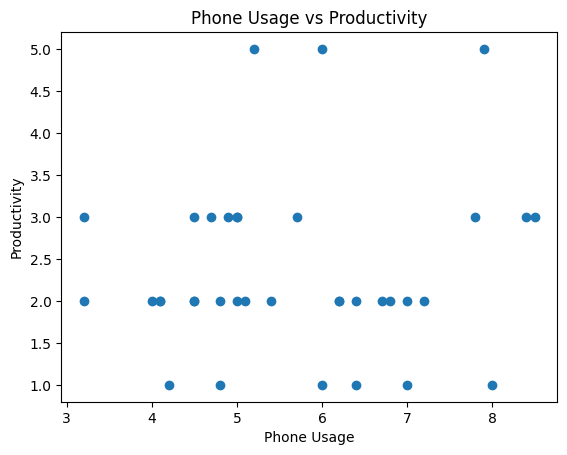

In [36]:
import matplotlib.pyplot as plt
plt.scatter(df["phone_usage"], df["productivity"])
plt.xlabel("Phone Usage")
plt.ylabel("Productivity")
plt.title("Phone Usage vs Productivity")
plt.show()

There is a weak relationship between phone usage and productivity.

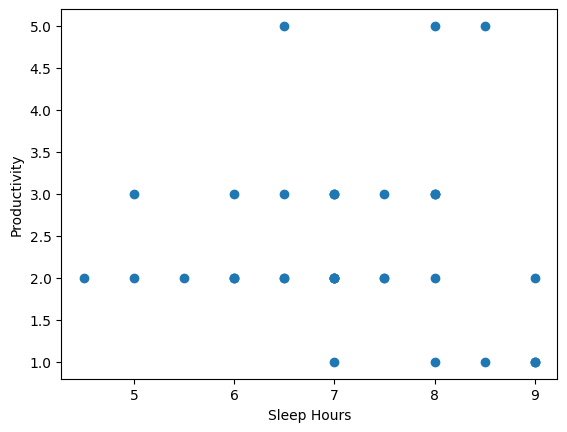

In [37]:
plt.scatter(df["sleep_hours"], df["productivity"])
plt.xlabel("Sleep Hours")
plt.ylabel("Productivity")
plt.show()

Sleep hours do not show a clear relationship with productivity.

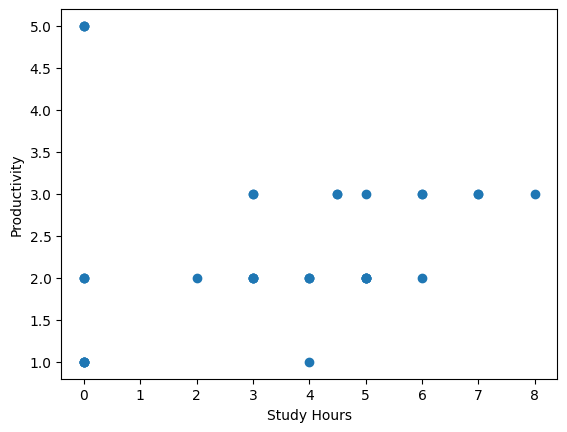

In [38]:
plt.scatter(df["study_hours"], df["productivity"])
plt.xlabel("Study Hours")
plt.ylabel("Productivity")
plt.show()

Study hours show a slight positive relationship with productivity.

<Axes: >

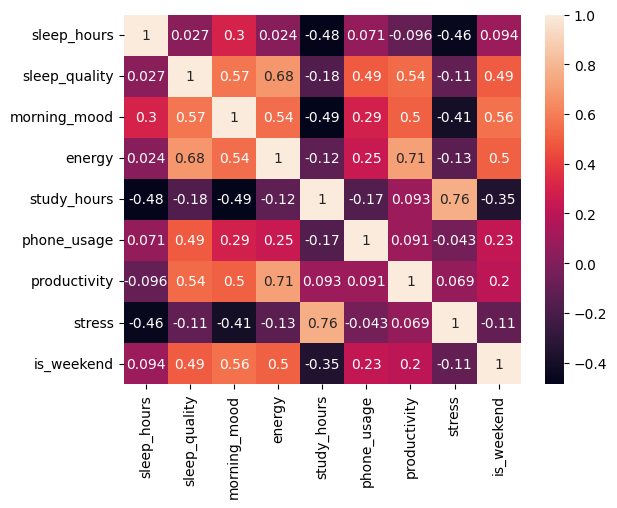

In [39]:
import seaborn as sns
df_numeric = df.select_dtypes(include=["number"])
sns.heatmap(df_numeric.corr(), annot=True)

Energy has the strongest correlation with productivity (r = 0.71), followed by morning mood.

In [40]:
from sklearn.linear_model import LinearRegression

X = df[["sleep_hours", "study_hours", "phone_usage", "energy", "morning_mood"]]
y = df["productivity"]
model = LinearRegression()
model.fit(X, y)
print(model.coef_)

[-0.06864029  0.12745707 -0.07766202  0.76366271  0.35377619]


Regression results indicate that energy is the most important predictor of productivity, followed by mood. Other variables have weak effects.

In [41]:
from scipy.stats import pearsonr

# Energy vs Productivity
corr, p_value = pearsonr(df["energy"], df["productivity"])
print("Energy vs Productivity:", corr, p_value)

# Mood vs Productivity
corr, p_value = pearsonr(df["morning_mood"], df["productivity"])
print("Mood vs Productivity:", corr, p_value)

# Phone vs Productivity
corr, p_value = pearsonr(df["phone_usage"], df["productivity"])
print("Phone vs Productivity:", corr, p_value)

Energy vs Productivity: 0.7107656832296362 1.1902184212661766e-06
Mood vs Productivity: 0.5032428296947036 0.0017569086638422333
Phone vs Productivity: 0.09140264054855107 0.5959918009523679


Hypothesis testing results show that energy has a statistically significant effect on productivity (p < 0.05). Morning mood also shows a significant relationship. However, phone usage does not have a statistically significant effect (p > 0.05).

Overall, the results suggest that internal factors such as energy and mood are more important than external behaviors in determining productivity.